In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
#from scar import setup_anndata
import warnings
import anndata
import numpy as np
import os
#import bbknn
warnings.simplefilter("ignore")

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import anndata
import scvi
import scanpy as sc

sc.set_figure_params(figsize=(4, 4))
scvi.settings.seed = 94705

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

Global seed set to 0
Global seed set to 94705


### GEX Preprocessing

SlicePS_L1:
donor0:GW19A, 7406
donor1:GW19B, 7550
donor2:GW22#201, 10860
donor3:GW20#200, 1265

SlicePS_L2:
donor0:GW19B, 10257
donor1:GW20#200, 1229
donor2:GW19A, 8995
donor3:GW22#201, 5771

In [82]:
import scanpy as sc
import pandas as pd
import os
fileList=['SlicePS_L1','SlicePS_L2']
adatas=[]
directory='/wynton/group/pollen/jding/brainchromatin/SlicePS/Cellbender/'
cellranger_dir='/wynton/group/pollen/jding/brainchromatin/SlicePS/cellranger'
vireo_dir='/wynton/group/pollen/jding/brainchromatin/SlicePS/vireo/'
sgRNA_dir = '/wynton/group/pollen/jding/brainchromatin/SlicePS/cellbouncer/cellbended'
sgRNA_dir = '/wynton/group/pollen/jding/brainchromatin/SlicePS/cellbouncer/guides'

f = fileList[0]
adata = sc.read_10x_h5(os.path.join(directory,f,'cellbended_filtered.h5'))
adata.obs['batch_name']=f
adata.obs['species'] = 'human'
#Add individual demux
df= pd.read_csv(os.path.join(vireo_dir,f,'donor_ids.tsv'),sep='\t',index_col=0)
df['individual'] = ['GW19#199-M' if id == 'donor0' else 'GW19#240719-F' if id == 'donor1' 
                    else 'GW22#201-F' if id == 'donor2' else 'GW20#200-F' if id == 'donor3' else id for id in df['donor_id']]
adata.obs['individual'] = df['individual']
#Add guide assignment
df= pd.read_csv(os.path.join(sgRNA_dir,f+'.assignments'),sep='\t',index_col=0,header=None)
df.columns = ["sgRNA_NKS", "num_guide_IDs",'log']
df.index =[x+'-1' for x in df.index]
for x in df.columns:
    adata.obs[x] = df[x] 
#Add STICR assignment
df= pd.read_csv(os.path.join(cellranger_dir,f,'outs/nextclone/assignments.csv'),index_col=2)
adata.obs['clone_barcode'] = df['clone_barcode']
adata.obs['clone_barcode_criteria'] = df['clone_barcode_criteria']
print (adata.obs.head())
adata.obs_names_make_unique()
adata.var_names_make_unique()
adatas.append(adata)

f = fileList[1]
adata = sc.read_10x_h5(os.path.join(directory,f,'cellbended_filtered.h5'))
adata.obs['batch_name']=f
adata.obs['species'] = 'human'
#Add individual demux
df= pd.read_csv(os.path.join(vireo_dir,f,'donor_ids.tsv'),sep='\t',index_col=0)
df['individual'] = ['GW19#240719-F' if id == 'donor0' else 'GW20#200-F' if id == 'donor1' 
                    else 'GW19#199-M' if id == 'donor2' else 'GW22#201-F' if id == 'donor3' else id for id in df['donor_id']]
adata.obs['individual'] = df['individual']
#Add guide assignment
df= pd.read_csv(os.path.join(sgRNA_dir,f+'.assignments'),sep='\t',index_col=0,header=None)
df.columns = ["sgRNA_NKS", "num_guide_IDs",'log']
df.index =[x+'-1' for x in df.index]
for x in df.columns:
    adata.obs[x] = df[x] 
#Add STICR assignment
df= pd.read_csv(os.path.join(cellranger_dir,f,'outs/nextclone/assignments.csv'),index_col=2)
adata.obs['clone_barcode'] = df['clone_barcode']
adata.obs['clone_barcode_criteria'] = df['clone_barcode_criteria']
print (adata.obs.head())
adata.obs_names_make_unique()
adata.var_names_make_unique()
adatas.append(adata)
adatas

import anndata
adata=anndata.AnnData.concatenate(*adatas, join='outer', batch_categories=fileList) 
#remove doublet/unassigned
adata = adata[adata.obs['individual'].isin(['GW19#199-M','GW19#240719-F','GW20#200-F','GW22#201-F'])]
adata.var_names_make_unique()
adata.obs_names_make_unique()
print(adata)

                    batch_name species  individual  \
GTAATCGTCCCGATCT-1  SlicePS_L1   human     doublet   
ATTCCCGTCGTCTACC-1  SlicePS_L1   human     doublet   
GCTGAATGTTTCACAG-1  SlicePS_L1   human     doublet   
GACTCTCCAGTTGCGC-1  SlicePS_L1   human     doublet   
CTTGATTTCCAAACCA-1  SlicePS_L1   human  GW20#200-F   

                                                            sgRNA_NKS  \
GTAATCGTCCCGATCT-1                                                 WT   
ATTCCCGTCGTCTACC-1  ARX_-_25033780.23-P1,SOX2_-_181430206.23-P1P2,...   
GCTGAATGTTTCACAG-1  ARX_+_25034044.23-P1,ARX_-_25033780.23-P1,NEUR...   
GACTCTCCAGTTGCGC-1  ARX_-_25033780.23-P1,NR2E1_+_108487374.23-P1P2...   
CTTGATTTCCAAACCA-1                                                 WT   

                    num_guide_IDs          log  \
GTAATCGTCCCGATCT-1            0.0     0.000000   
ATTCCCGTCGTCTACC-1            4.0    13.995388   
GCTGAATGTTTCACAG-1           14.0  3501.048491   
GACTCTCCAGTTGCGC-1            6.0  1

In [83]:
import numpy as np
ribo_genes=[name for name in adata.var_names if name.startswith('RPS') or name.startswith('RPL') ]
adata.obs['percent_ribo'] = np.sum(
adata[:, ribo_genes].X, axis=1) / np.sum(adata.X, axis=1)
mito_genes = [name for name in adata.var_names if name in ['ND1','ND2','ND4L','ND4','ND5','ND6','ATP6','ATP8','CYTB','COX1','COX2','COX3'] or name.startswith('CHRM-') or name.startswith('MT-')]
adata.obs['percent_mito'] = np.sum(
adata[:, adata.var.index.isin(mito_genes)].X, axis=1) / np.sum(adata.X, axis=1)
print(adata)

AnnData object with n_obs × n_vars = 52058 × 38606
    obs: 'batch_name', 'species', 'individual', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'percent_ribo', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome'


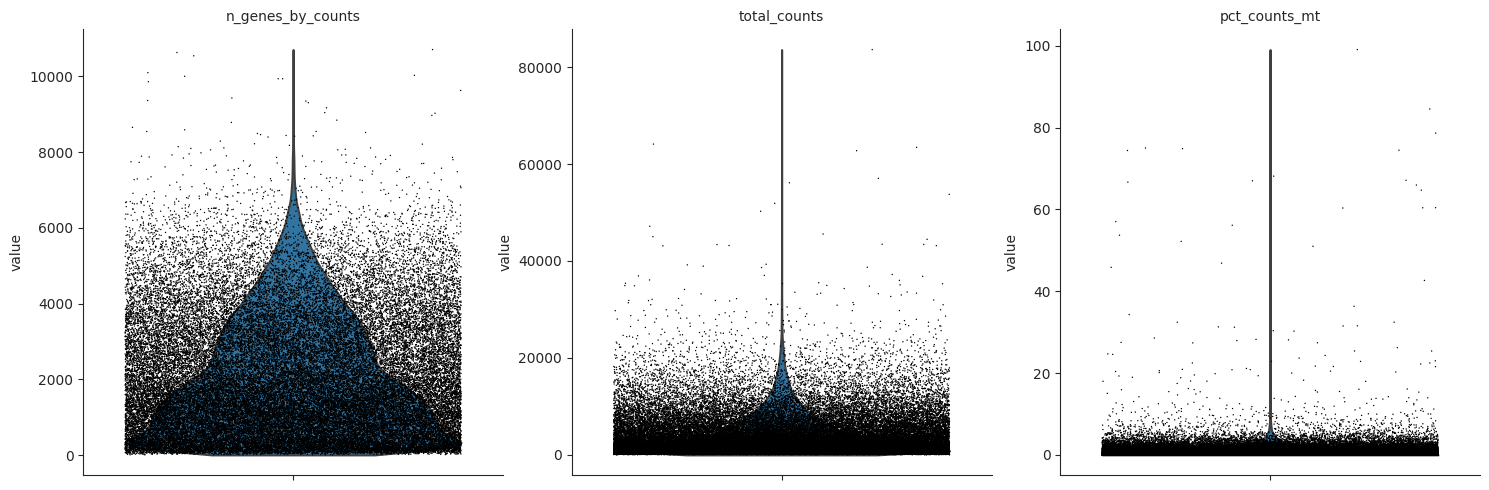

In [84]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [85]:
adata._inplace_subset_obs(adata.obs['percent_ribo']<.4)
adata._inplace_subset_obs(adata.obs['percent_mito']<.15)
adata._inplace_subset_var(~adata.var.index.isin(mito_genes))
adata

AnnData object with n_obs × n_vars = 51967 × 38593
    obs: 'batch_name', 'species', 'individual', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'percent_ribo', 'percent_mito', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [86]:
#adata.raw = adata
#sc.pp.filter_genes(adata,min_cells=10)
sc.pp.filter_cells(adata, min_genes=300)
adata

AnnData object with n_obs × n_vars = 46675 × 38593
    obs: 'batch_name', 'species', 'individual', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'percent_ribo', 'percent_mito', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [87]:
#rename/merge guide info
adata.obs['gene_NKS'] = [','.join(list(set([i.split('_')[0] for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
adata.obs['num_gene_NKS'] = [len(list(set([i.split('_')[0] for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
#adata = adata[adata.obs['num_gene_NKS'].isin([1,2])]
adata.obs['gene_NKS'] =[x.replace('non-targeting,','') for x in adata.obs['gene_NKS']] 
adata.obs['gene_NKS'] =[x.replace(',non-targeting','') for x in adata.obs['gene_NKS']] 

In [88]:
feature_ref = df= pd.read_csv('/wynton/home/pollenlab/jding/BrainChromatin/Perturb/cellranger/feature_ref.csv',index_col=0)
feature_ref['guide_name'] = feature_ref['target_gene_name'] + '_' +  feature_ref['guideID']
dic = dict(map(lambda i,j : (i,j) , feature_ref.index, feature_ref['guide_name']))
dic

{'KLF10_-_103668072.23-P1': 'KLF10_g1',
 'KLF10_-_103668064.23-P1': 'KLF10_g2',
 'KLF10_-_103667898.23-P1': 'KLF10_g3',
 'ZBTB18_ATGGGGAGCCGTTGAGAGTG': 'ZBTB18_g1',
 'ZBTB18_CCATGGCAGCAGCCCAGCGG': 'ZBTB18_g2',
 'ZBTB18_GAAGAGGGCCCCACTCTCAA': 'ZBTB18_g3',
 'NR2E1_+_108487374.23-P1P2': 'NR2E1_g1',
 'NR2E1_-_108487507.23-P1P2': 'NR2E1_g2',
 'NR2E1_-_108487770.23-P1P2': 'NR2E1_g3',
 'VEZF1_-_56065595.23-P1P2': 'VEZF1_g1',
 'VEZF1_-_56065555.23-P1P2': 'VEZF1_g2',
 'VEZF1_-_56065552.23-P1P2': 'VEZF1_g3',
 'ZNF441_+_11877881.23-P1P2': 'ZNF441_g1',
 'ZNF441_-_11878061.23-P1P2': 'ZNF441_g2',
 'ZNF441_-_11877838.23-P1P2': 'ZNF441_g3',
 'NFIA_+_61548485.23-P1P2': 'NFIA_g1',
 'NFIA_-_61548230.23-P1P2': 'NFIA_g2',
 'NFIA_-_61548500.23-P1P2': 'NFIA_g3',
 'NFIB_+_14314559.23-P1P2': 'NFIB_g1',
 'NFIB_+_14314562.23-P1P2': 'NFIB_g2',
 'NFIB_-_14314072.23-P1P2': 'NFIB_g3',
 'ZNF148_-_125093949.23-P1P2': 'ZNF148_g1',
 'ZNF148_+_125093932.23-P1P2': 'ZNF148_g2',
 'ZNF148_+_125093703.23-P1P2': 'ZNF148_g3',
 

In [89]:
adata.obs['sgRNA'] = [','.join(list(set([dic[i] if i in dic.keys() else i for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
adata.obs['num_sgRNA'] = [len(list(set(x.split(',')))) for x in adata.obs['sgRNA'].astype(str)]
adata.obs['sgRNA_effecitve'] = [','.join(list(set(i for i in x.split(',') if not 'Non-Targeting' in i))) for x in adata.obs['sgRNA'].astype(str)]

In [90]:
adata.write('/wynton/group/pollen/jding/brainchromatin/SlicePS/Cellbender/SlicePS.h5ad')

## Visualization

In [20]:
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
adata = sc.read(os.path.join(directory,'query_Slice.raw.h5ad'), compression='gzip')
adata.obs['Gene_target'] = adata.obs['gene_NKS']
#adata = adata[adata.obs['Gene_target'].isin(targets)]
adata.obs['sex'] = [x.split('-')[-1] for x in adata.obs['individual']]
adata.obs['stage'] = [x.split('#')[0] for x in adata.obs['individual']]
adata.obs['perturbation'] = ['NT' if x in ['WT','non-targeting'] else 'Perturbed' for x in adata.obs['gene_NKS']]

/scratch/jding/ipykernel_792468/3507407600.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Gene_target'] = adata.obs['gene_NKS']


In [3]:
adata.obs['individual'].value_counts()

individual
GW19#199-M       3909
GW19#240719-F    3416
GW22#201-F       2394
GW20#200-F        348
Name: count, dtype: int64

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


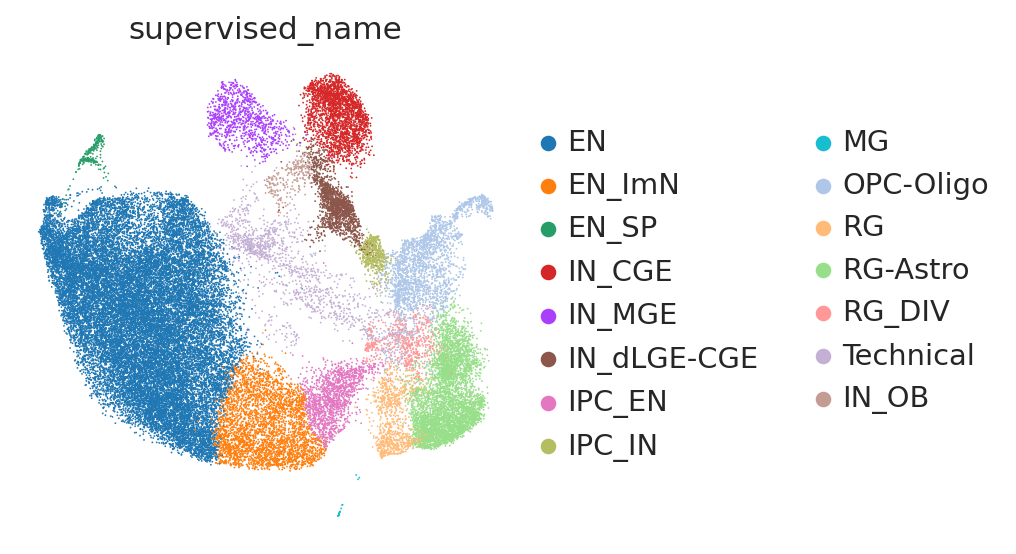

In [80]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (4, 4)
sc.settings.file_format_figs='svg'
sc.pl.umap(adata, color=['supervised_name'], 
           frameon=False, legend_fontsize=13, legend_fontoutline=3,save='slice_leiden')

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


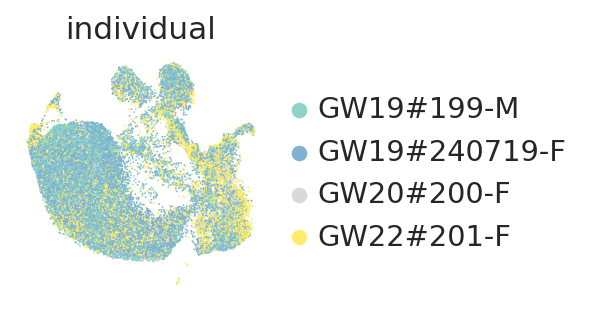

In [88]:
rcParams["figure.figsize"] = (2, 2)
sc.settings.file_format_figs='pdf'
sc.pl.umap(adata, color=['individual'],frameon=False, legend_fontsize=13, legend_fontoutline=3,
           palette='Set3',ncols=1,save='distribution-slice')

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


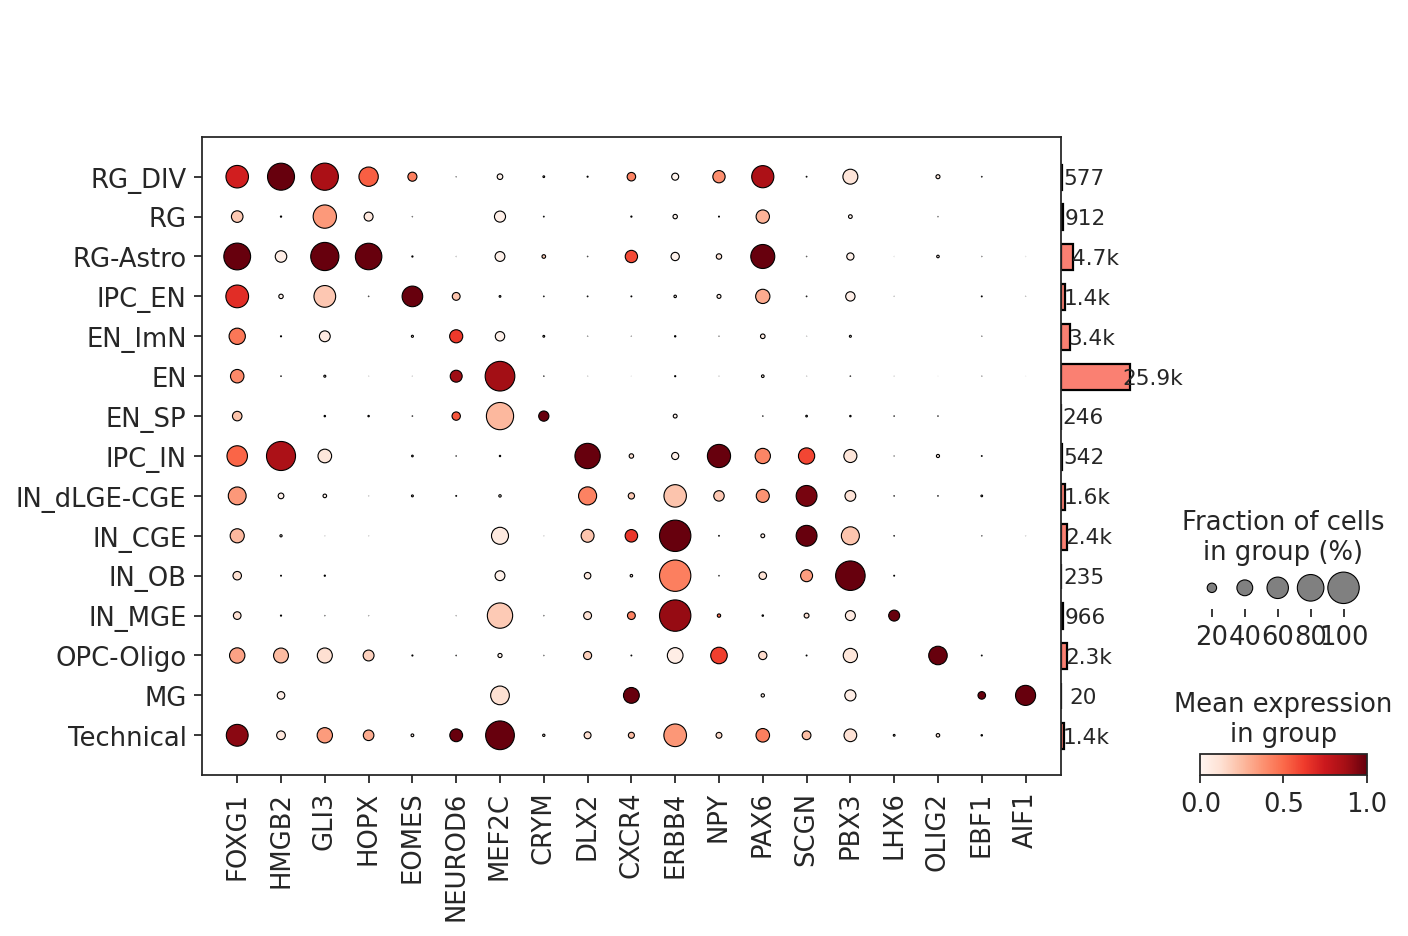

In [27]:
adata.obs['supervised_name'] = adata.obs['supervised_name'].astype('category')
#sc.tl.dendrogram(adata, 'supervised_name')
dp = sc.pl.dotplot(adata, ['FOXG1','HMGB2','GLI3','HOPX','EOMES','NEUROD6','MEF2C','CRYM','DLX2','CXCR4','ERBB4','NPY','PAX6','SCGN','PBX3','LHX6','OLIG2','EBF1','AIF1'],
                   'supervised_name', categories_order = ['RG_DIV','RG','RG-Astro','IPC_EN','EN_ImN','EN','EN_SP','IPC_IN','IN_dLGE-CGE','IN_CGE','IN_OB','IN_MGE','OPC-Oligo','MG','Technical'],
                                 standard_scale='var',dot_max=0.6, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5,cmap='Reds' ).savefig("./figures/dotplot.pdf")

In [31]:
adata = adata[adata.obs['gene_NKS'].isin(['non-targeting', 'NR2E1', 'SOX2', 'NEUROD2', 'ARX', 'ZNF219'])]

In [32]:
adata = adata[adata.obs["clone_barcode_criteria"] != 'no_clones_found']
adata.obs["unique_clone"] = adata.obs["clone_barcode"].astype(str) + adata.obs["individual"].astype(str)
adata.obs["time_info"] = '0'
adata.obs["time_info"].value_counts()

/scratch/jding/ipykernel_792468/3640936254.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["unique_clone"] = adata.obs["clone_barcode"].astype(str) + adata.obs["individual"].astype(str)


time_info
0    9533
Name: count, dtype: int64

<Axes: xlabel='max_percentage', ylabel='Count'>

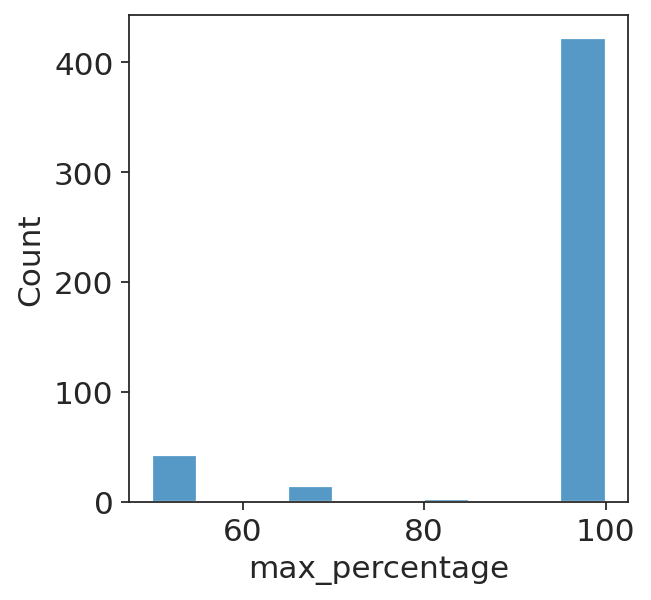

In [33]:
df = adata.obs.groupby(["unique_clone","sgRNA"]).size().reset_index(name="count")
df = df[df['count'] != 0]
df['total_count'] = df.groupby('unique_clone')['count'].transform('sum')
df['percentage'] = (df['count'] / df['total_count']) * 100
df['max_percentage'] = df.groupby('unique_clone')['percentage'].transform('max')
df = df.sort_values(by='max_percentage', ascending=False)
df = df.drop_duplicates(subset='unique_clone', keep="first")
import seaborn 
sns.histplot(data=df[df['total_count'] > 1], x="max_percentage")

In [34]:
adata = adata[adata.obs['unique_clone'].isin(df[df['max_percentage'] == 100]['unique_clone'])]

/scratch/jding/ipykernel_792468/2582232886.py:3: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["data_des"] = "/wynton/scratch/jding/Cellranger-7.2.0"
100%|██████████████████████████████████| 9370/9370 [00:00<00:00, 1123934.81it/s]


reorder clones
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
Results saved as dictionary at adata.uns['fate_coupling_X_clone']


FileNotFoundError: [Errno 2] No such file or directory: 'figure/0_fate_coupling_X_clone.pdf'

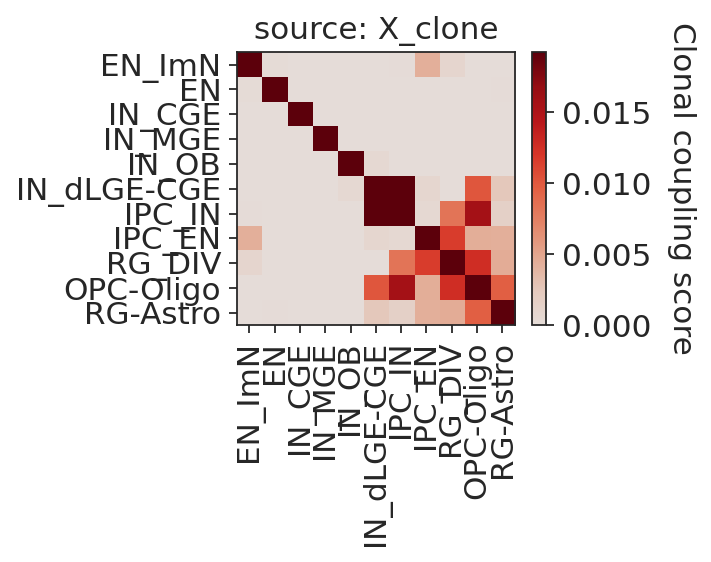

In [15]:
import cospar as cs
selected_fates = ['IPC_IN', 'RG_DIV',  'RG-Astro','OPC-Oligo', 'EN', 'IN_dLGE-CGE','IN_CGE','IN_MGE', 'IN_OB','IPC_EN','EN_ImN']
adata.uns["data_des"] = "/wynton/scratch/jding/Cellranger-7.2.0"
sub = adata
cs.pp.get_X_clone(sub,sub.obs.index.tolist(),sub.obs.unique_clone.tolist())
sub.obs["state_info"] = sub.obs['supervised_name'].astype(str)
cs.tl.fate_coupling(sub,source='X_clone',selected_fates=selected_fates) # compute the fate coupling
cs.pl.fate_coupling(sub,source='X_clone') # actually plot the coupling

/wynton/home/pollenlab/jding/miniconda3/envs/cospar/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


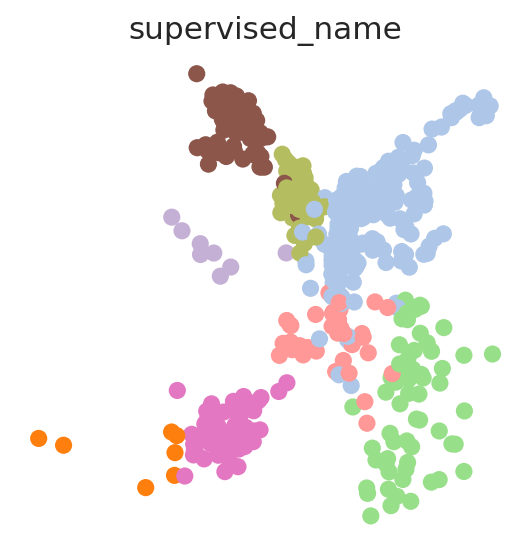

In [18]:
#clones >2 cells
df = adata.obs['unique_clone'].value_counts().reset_index(name='cellcounts')
multiclones = df[df['cellcounts'] > 2]['unique_clone'].values
adata = adata[adata.obs['unique_clone'].isin(multiclones)]
sc.pl.umap(adata, color='supervised_name', legend_loc='none',
           frameon=False, legend_fontsize=13, legend_fontoutline=3,save = 'multiclones_leiden')

Text(0.5, 0, '')

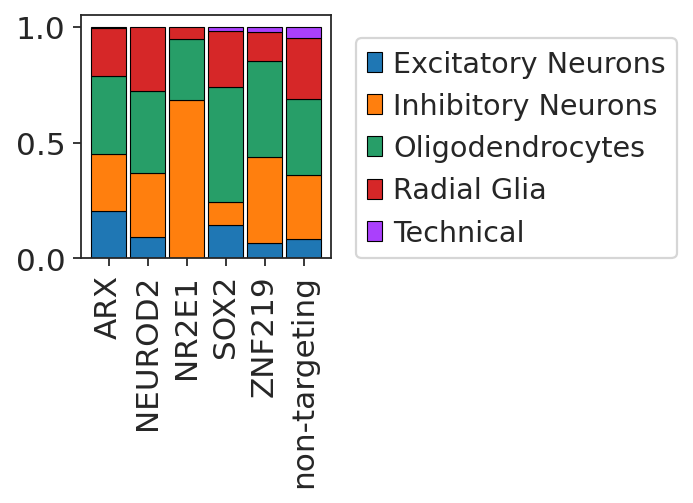

In [40]:
sub = adata[adata.obs['species'].isin(['human'])]
sub = sub[sub.obs['gene_NKS'].isin(['non-targeting', 'NR2E1', 'SOX2', 'NEUROD2', 'ARX', 'ZNF219'])]
clonal_cluster_count = sub.obs.groupby([ "gene_NKS","class"]).size().reset_index().pivot(
    columns="class", index="gene_NKS", values=0
)
clonal_cluster_count = clonal_cluster_count[clonal_cluster_count.columns[clonal_cluster_count.columns != "NA"]]
clonal_cluster_count = clonal_cluster_count[clonal_cluster_count.sum(axis=1) > 5]
clonal_cluster_count = (clonal_cluster_count.T / clonal_cluster_count.sum(axis=1)).T

fig, ax = plt.subplots(figsize=(2, 2))
ax = clonal_cluster_count.plot(kind="bar", stacked=True, width=0.9, edgecolor="black",
                               #color=dict(zip(clones.obs.gene_NKS.cat.categories, clones.uns["perturbation_colors"])),
                               ax=ax, linewidth=0.5)
ax.legend(loc=(1.1, 0))
ax.set_xlabel("")

### Clustering IN populations

In [72]:
import scanpy as sc 
import os
directory='/wynton/group/pollen/jding/brainchromatin/Li'
adata_query = sc.read(os.path.join(directory,'query_Slice.raw.h5ad'), compression='gzip')
adata_query = adata_query[adata_query.obs['batch'] == 'SlicePS']
adata_query.obs['Gene_target'] = adata_query.obs['gene_NKS']
targets = [x for x in adata_query.obs['Gene_target'].unique() if x in adata_query.var_names]
targets.append('non-targeting')
adata_query = adata_query[adata_query.obs['Gene_target'].isin(targets)]
adata_query.obs['sex'] = [x.split('-')[-1] for x in adata_query.obs['individual']]
adata_query.obs['stage'] = [x.split('#')[0] for x in adata_query.obs['individual']]
adata_query.obs['perturbation'] = ['NT' if x in ['WT','non-targeting'] else 'Perturbed' for x in adata_query.obs['gene_NKS']]

In [39]:
#subset local cluster
adata_query = adata_query[adata_query.obs['supervised_name'].isin(['IN_dLGE-CGE'])]

In [74]:
adata_query.raw = adata_query.copy()
sc.pp.normalize_total(adata_query,exclude_highly_expressed=True)
sc.pp.log1p(adata_query)
sc.pp.highly_variable_genes(adata_query, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_query,max_value=10)
sc.pp.pca(adata_query,n_comps=100)
sc.pp.neighbors(adata_query, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_query)

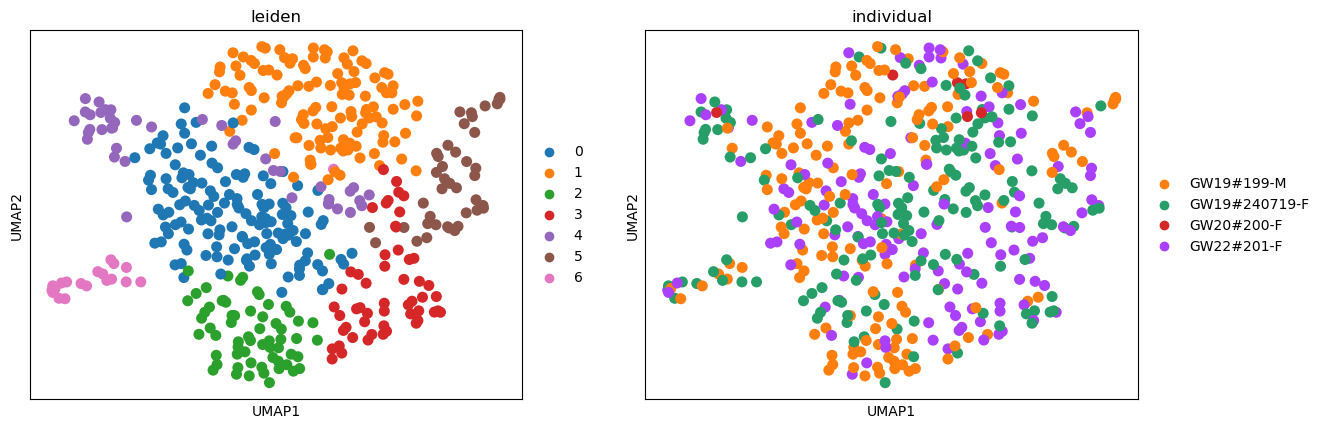

In [41]:
sc.tl.leiden(adata_query, resolution = 0.6)
sc.pl.umap(adata_query, color=['leiden','individual'])

In [42]:
old_to_new = {
    '0':'IN_CALB2/FBN2',
    '1':'IN_LMO1/RIC3',
    '2':'IN_CALB2/FBN2',
    '3':'IN_NFIA/ST18',
    '4':'IN_PBX3/GRIA1',
    '5':'IN_PAX6/ST18',
    '6':'IN_CALB2/SPOCK1'
}
adata_query.obs['subtype'] = (
    adata_query.obs['leiden']
    .map(old_to_new)
    .astype('category')
)

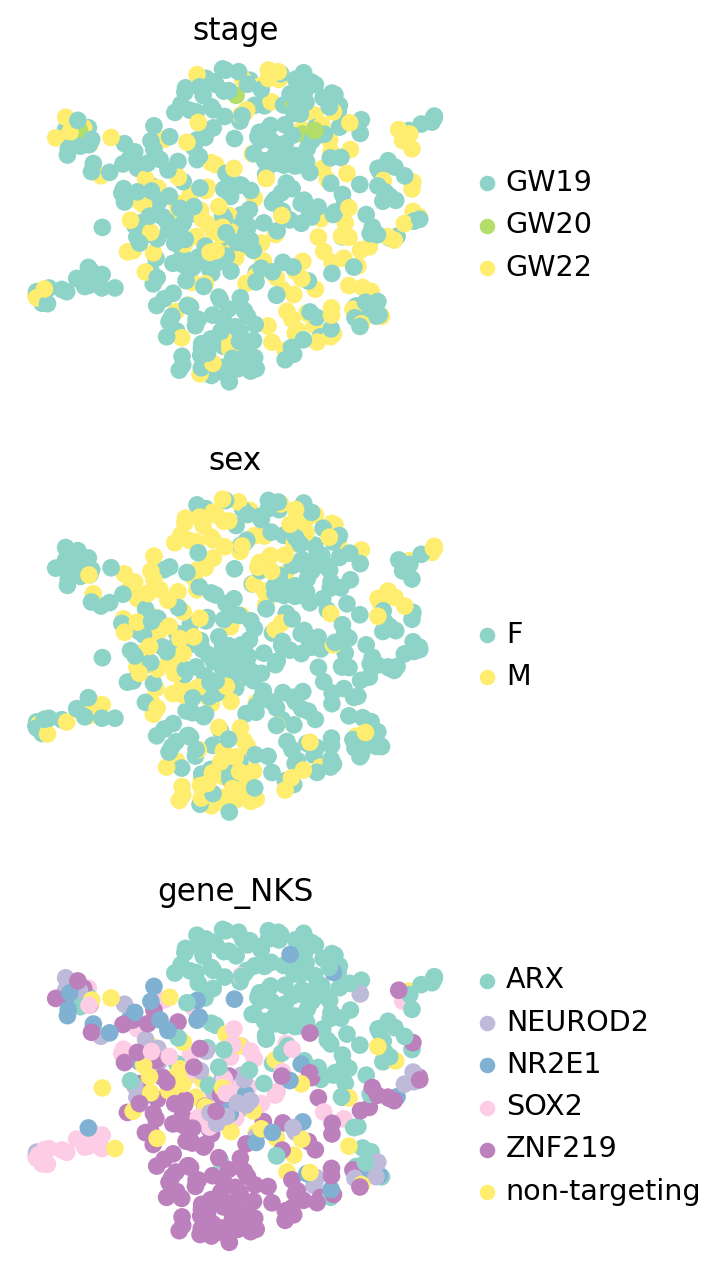

In [89]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata_query, color=['stage','sex','gene_NKS'], palette='Set3',frameon=False ,ncols=1,save ='distribution-IN-slice')

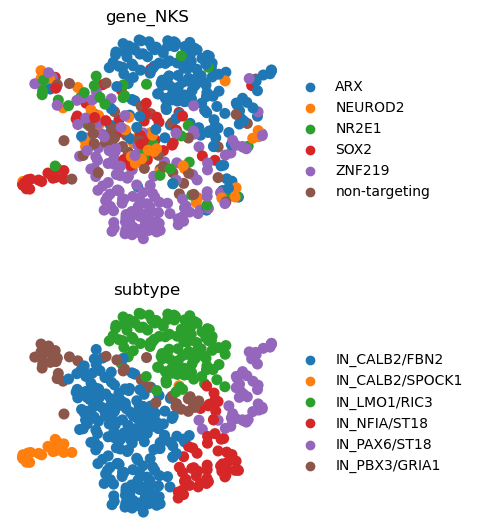

In [67]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata_query,color=['gene_NKS',"subtype"],frameon=False,ncols=1, palette = sc.pl.palettes.vega_10,save = 'IN_subtype')

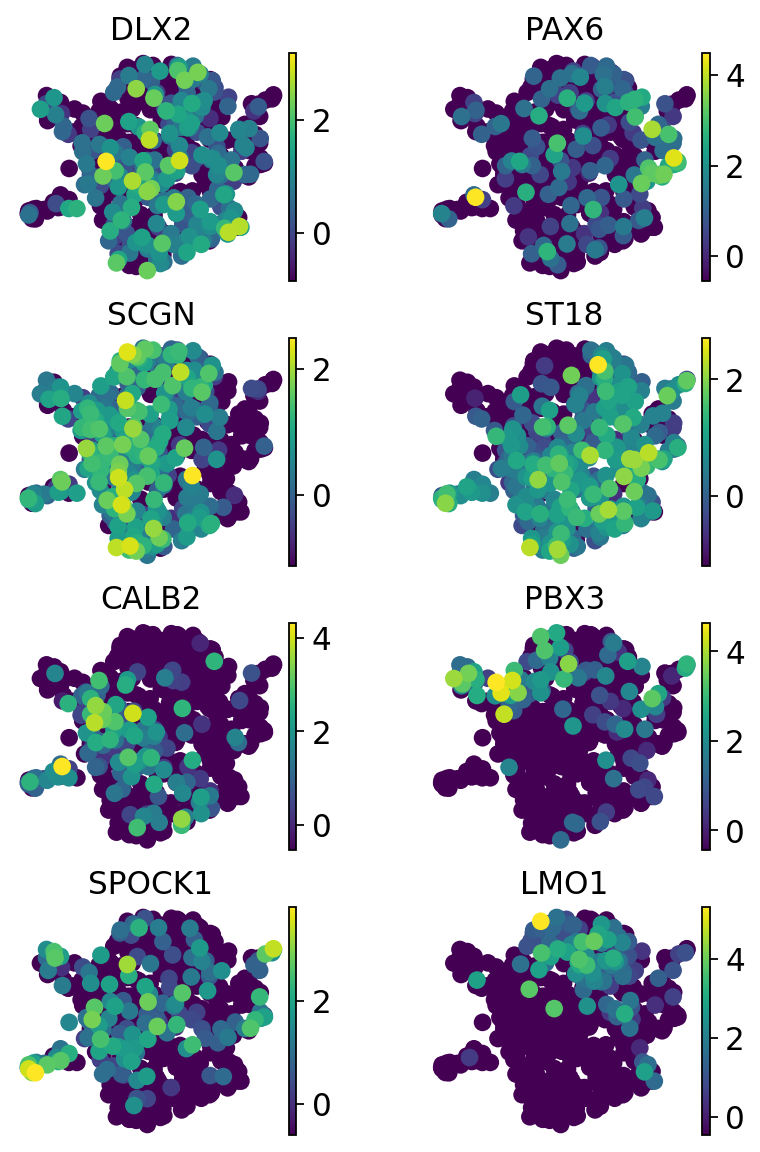

In [95]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
sc.pl.umap(adata_query, color=['DLX2','PAX6','SCGN','ST18','CALB2','PBX3','SPOCK1','LMO1'],use_raw=False,
           frameon=False, legend_fontsize=13, legend_fontoutline=3,ncols=2 ,save = 'IN_8genes_slice')

In [73]:
#all INs
adata_query = adata_query[adata_query.obs['supervised_name'].isin(['IN_dLGE-CGE','IN_MGE','IN_OB','IN_CGE'])]

In [74]:
adata_query.raw = adata_query.copy()
sc.pp.normalize_total(adata_query,exclude_highly_expressed=True)
sc.pp.log1p(adata_query)
sc.pp.highly_variable_genes(adata_query, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_query,max_value=10)
sc.pp.pca(adata_query,n_comps=100)
sc.pp.neighbors(adata_query, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_query)

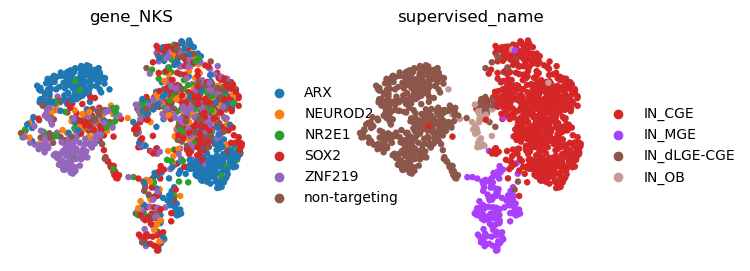

In [84]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (3, 3)
sc.tl.leiden(adata_query, resolution = 0.6)
sc.pl.umap(adata_query, color=['gene_NKS','supervised_name'], frameon=False)

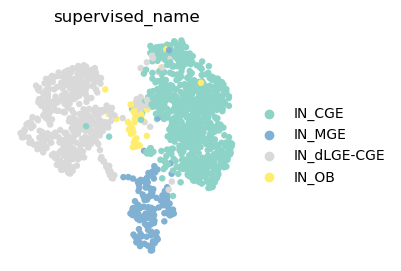

In [86]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (3, 3)
sc.tl.leiden(adata_query, resolution = 0.6)
sc.pl.umap(adata_query, color=['supervised_name'], frameon=False,palette='Set3',ncols=1,save='GE_IN')

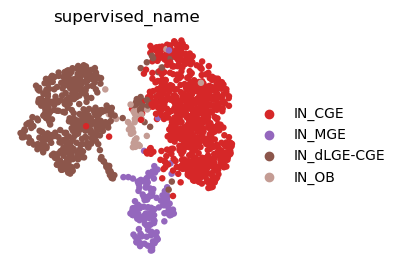

In [91]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (3, 3)
sc.tl.leiden(adata_query, resolution = 0.6)
sc.pl.umap(adata_query, color=['supervised_name'], frameon=False,palette={'IN_CGE':'#d62728','IN_MGE':'#9467bd','IN_dLGE-CGE':'#8c564b','IN_OB':'#c49c94'},ncols=1,save='GE_IN')

In [82]:
directory='/wynton/group/pollen/jding/brainchromatin/Li'
adata_query.X = adata_query.raw.X
adata_query.write(os.path.join(directory,'query_Slice.IN.h5ad'), compression='gzip')

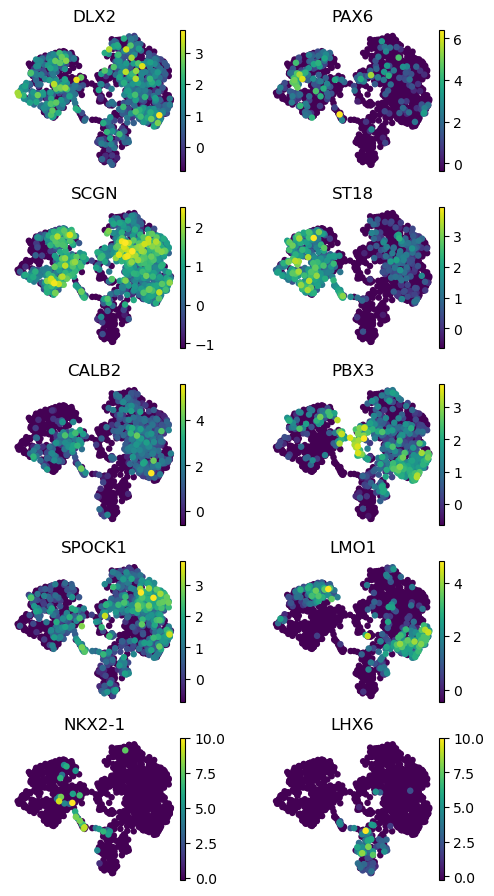

In [77]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
sc.pl.umap(adata_query, color=['DLX2','PAX6','SCGN','ST18','CALB2','PBX3','TSHZ1','SPOCK1','LMO1','LHX6'],use_raw=False,
           frameon=False, legend_fontsize=13, legend_fontoutline=3,ncols=2 )#save = 'IN_8genes_slice')

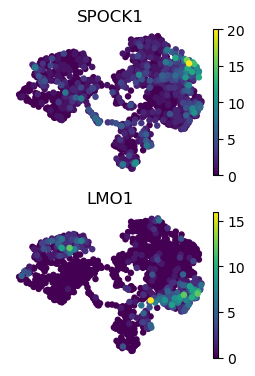

In [94]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
sc.pl.umap(adata_query, color=['SPOCK1','LMO1'],use_raw=False,
           frameon=False, legend_fontsize=13, legend_fontoutline=3,ncols=1 ,save = 'IN_2genes_slice')

In [107]:
directory='/wynton/group/pollen/jding/brainchromatin/Li'
adata_query.X  = adata_query.raw.X
adata_query.write(os.path.join(directory,'query_Slice.IN.h5ad'), compression='gzip')